# HSC Measurement

> Measurements of the ICL for a [worked example](05_hsc_analysis.ipynb) of analysing the ICL in images from the HSC-SSP deep survey.

In [ ]:
# | default_exp hsc.measurement

In [ ]:
# | hide
from os.path import join

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
from astropy.visualization import AsinhStretch, ImageNormalize

from nicl.hsc.preparation import f21_cluster_image, get_f21_table2
from nicl.measure import (
    background_correct_profile,
    calculate_icl_isophotes,
    calculate_icl_profile,
    ellipse_patch,
    estimate_icl_shape,
    plot_icl,
    profile_from_isolists,
)
from nicl.utilities import get_cutout

In the following we will assume the full mask has already been created by following the procedure in [HSC Masking](02_hsc_masking.ipynb). 

In [ ]:
local_data_path = "/Users/spb/data/hsc/"

Get an image to demonstrate the process.

In [ ]:
cluster = get_f21_table2()[0]
filter = "i"

In [ ]:
img, mask, sigma = f21_cluster_image(
    cluster["XCS ID"], filter, local_data_path, return_hdus=True
)

/Users/spb/data/hsc/XMMXCS_J022456.1-050802.0/XMMXCS_J022456.1-050802.0_i.fits


Get the previously created masks.

In [ ]:
def read_mask(name):
    fn = join(local_data_path, cluster["XCS ID"].replace(" ", "_"), f"{name}.fits")
    return fits.getdata(fn)

In [ ]:
bcg_mask = read_mask("bcg_mask").astype(bool)
full_mask = read_mask("full_mask").astype(bool)

## Measuring the ICL profile

There are various approaches we could take to measure the ICL profile. For now, we estimate it by assuming the ICL has concentric elliptical isophotes with a fixed ellipticity. We could also allow flexibility using [photutils.isophote](https://photutils.readthedocs.io/en/stable/isophote.html).

### Measuring the ICL shape

We first need to estimate the ellipticity and position angle of the ICL, to define the annuli in which we will measure the radial profile. To do so, we measure the eigenvectors and eigenvalues of the ICL. This method does a reasonable job, but may be influenced by significant masking, noise and unsubtracted background features.

In [ ]:
pa, ax_ratio, centre, semimajoraxis = estimate_icl_shape(
    img, full_mask, cluster["R_X_arcsec"]
)
print(pa, ax_ratio, centre, semimajoraxis)

54.9361595000092 0.6615130997106813 [0. 0.] 209.63487864158634


In [ ]:
cutout, mask = get_cutout(
    img, 0.8 * cluster["R_X_arcsec"], position=None, mask=full_mask
)

### Measuring the profile with concentric elliptical annuli

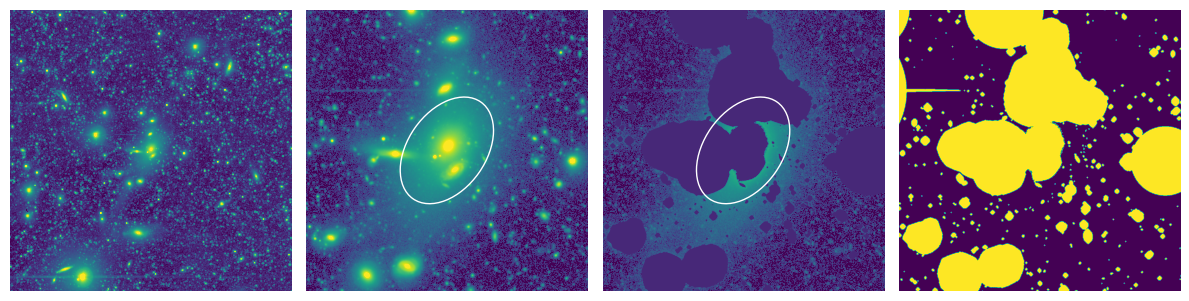

In [ ]:
fig, ax = plt.subplots(1, 4, figsize=(12, 5))
norm = ImageNormalize(vmin=-0.01, vmax=10, stretch=AsinhStretch(0.001))
ax[0].imshow(img, norm=norm, origin="lower")
ax[1].imshow(cutout, norm=norm, origin="lower")
ax[1].add_patch(ellipse_patch(cutout, centre, semimajoraxis, ax_ratio, pa))
masked = np.where(mask, 0, cutout)
ax[2].imshow(masked, norm=norm, origin="lower")
ax[2].add_patch(ellipse_patch(masked, centre, semimajoraxis, ax_ratio, pa))
ax[3].imshow(mask, origin="lower")
for a in ax:
    a.axis("off")
plt.tight_layout()

In [ ]:
%%time
profile, icl_shape = calculate_icl_profile(
    img, full_mask, cluster["R_X_arcsec"], annulus_width_pix=50
)

CPU times: user 2min 18s, sys: 15.6 s, total: 2min 33s
Wall time: 2min 35s


In [ ]:
background_profile = profile[profile["semimajoraxis_r500"] > 1.0]
bkg, profile = background_correct_profile(
    background_profile, profile, img, zp=27 * u.ABmag
)

background for mean is 0.0022 ± 0.0005
background for median is 0.0019 ± 0.0005


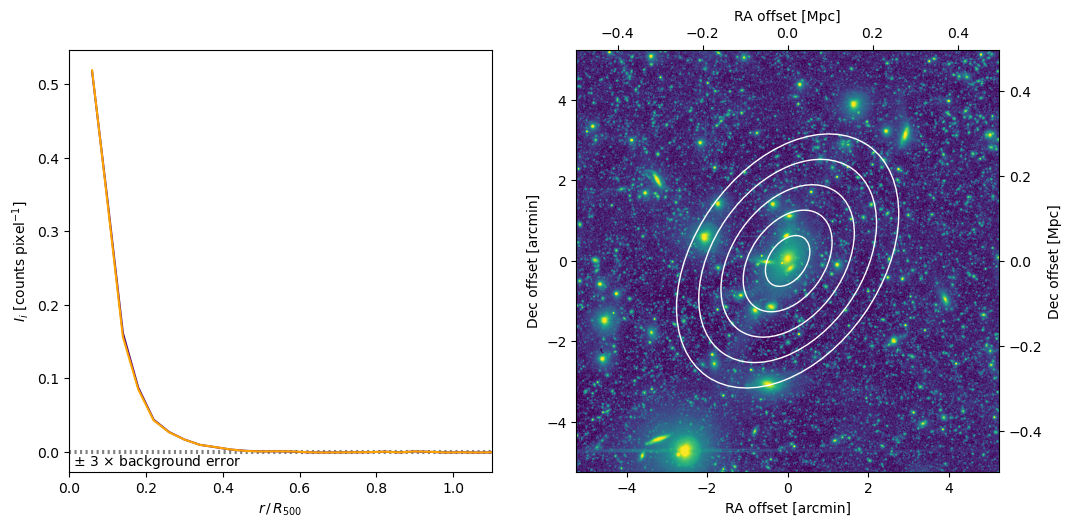

In [ ]:
plot_icl(
    img,
    profile,
    icl_shape,
    cluster["z"],
    surface_brightness=False,
    radius="semimajoraxis_r500",
    bkg=bkg,
    norm=norm,
)

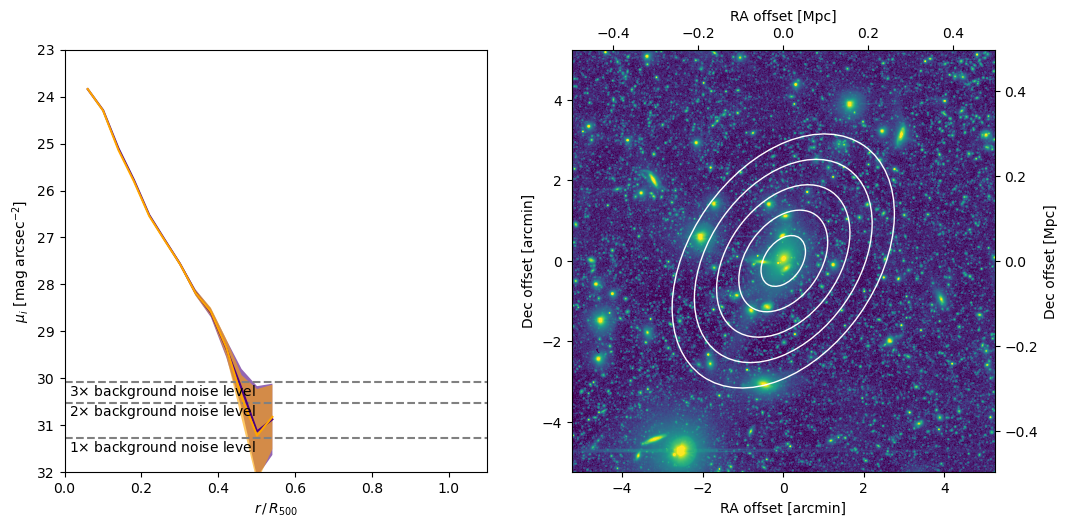

In [ ]:
plot_icl(
    img,
    profile,
    icl_shape,
    cluster["z"],
    surface_brightness=True,
    radius="semimajoraxis_r500",
    bkg=bkg,
    norm=norm,
)

### Fitting elliptial isophotes

In [ ]:
%%time
isolists = calculate_icl_isophotes(img, full_mask, bcg_mask, cluster["R_X_arcsec"])

/Users/spb/anaconda/envs/icl/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/spb/anaconda/envs/icl/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/spb/anaconda/envs/icl/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/spb/anaconda/envs/icl/lib/python3.12/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/Users/spb/anaconda/envs/icl/lib/python3.12/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


CPU times: user 20min 14s, sys: 8.6 s, total: 20min 23s
Wall time: 20min 26s


In [ ]:
# This does not work
# %%time
# model_image = build_ellipse_model(img.shape, isolists['median'])

In [ ]:
isoprofile = profile_from_isolists(isolists, img, cluster["R_X_arcsec"])

In [ ]:
background_isoprofile = isoprofile[isoprofile["semimajoraxis_r500"] > 0.6]
isobkg, isoprofile = background_correct_profile(
    background_isoprofile, isoprofile, img, zp=27 * u.ABmag
)

background for mean is 0.0018 ± 0.0007
background for median is 0.0014 ± 0.0008


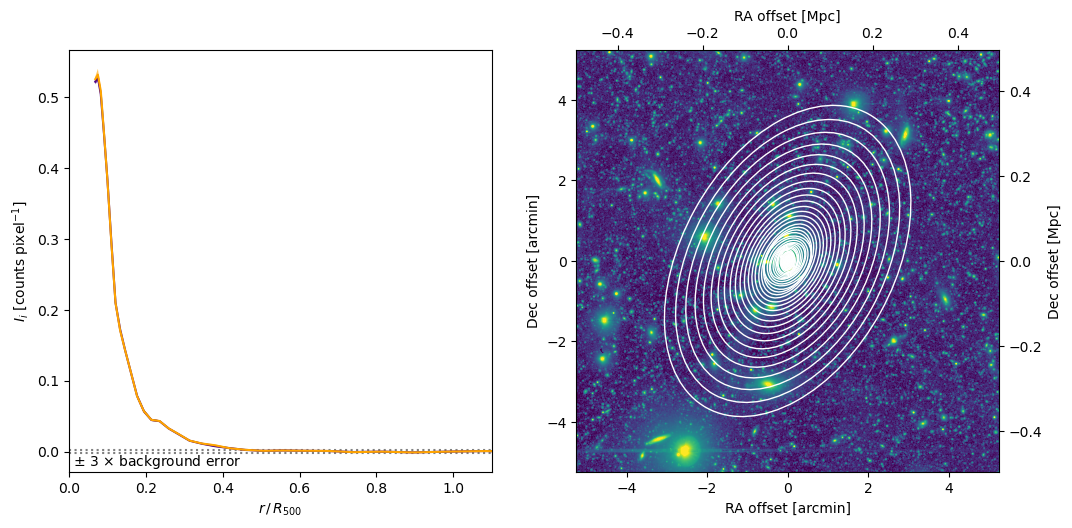

In [ ]:
plot_icl(
    img,
    isoprofile,
    isolists["median"],
    cluster["z"],
    surface_brightness=False,
    radius="semimajoraxis_r500",
    bkg=isobkg,
    norm=norm,
)

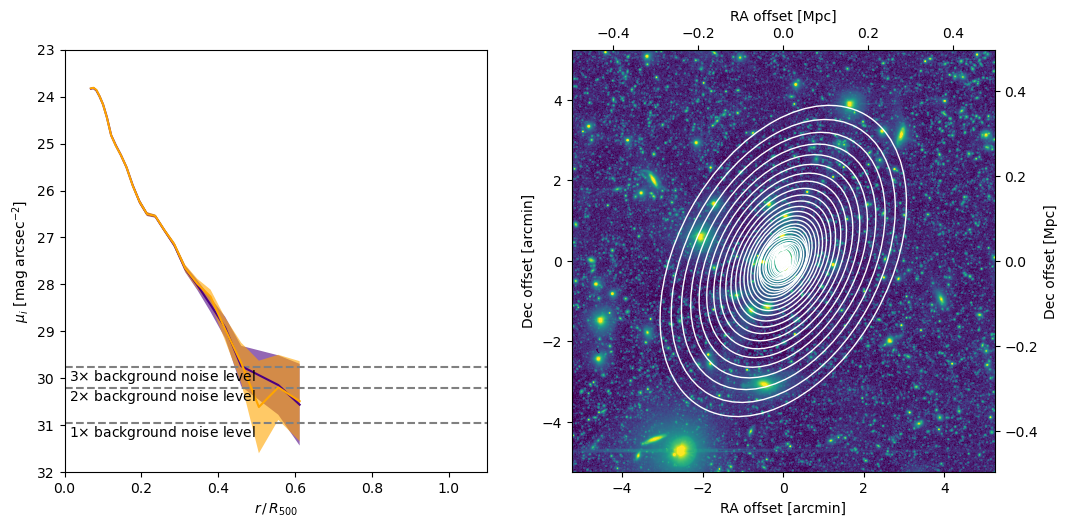

In [ ]:
plot_icl(
    img,
    isoprofile,
    isolists["median"],
    cluster["z"],
    surface_brightness=True,
    radius="semimajoraxis_r500",
    bkg=isobkg,
    norm=norm,
)

In [ ]:
# | hide
import nbdev

nbdev.nbdev_export()